### Loading the cleaned master dataset

In [34]:
import pandas as pd

master_clean = pd.read_csv(
    "../data/processed/master_clean.csv",
    parse_dates=["utc_timestamp", "time"]
)

master_clean.head()

,utc_timestamp,DE_load_actual_entsoe_transparency,DE_solar_generation_actual,DE_wind_generation_actual,DE_solar_capacity,DE_wind_capacity,DE_LU_price_day_ahead,time,temperature_C,humidity_pct,...,wind_speed_ms,precipitation_mm,hour,day_of_week,month,year,is_weekend,quarter,week_of_year,season
0,2015-01-01 00:00:00+00:00,41151.0,71.0,8852.0,37248.0,27913.0,NaN,2015-01-01 00:00:00+00:00,0.96,94.4,...,8.50,0.0,0,3,1,2015,0,1,1,Winter
1,2015-01-01 01:00:00+00:00,40135.0,71.0,9054.0,37248.0,27913.0,NaN,2015-01-01 01:00:00+00:00,0.62,94.4,...,8.72,0.0,1,3,1,2015,0,1,1,Winter
2,2015-01-01 02:00:00+00:00,39106.0,71.0,9070.0,37248.0,27913.0,NaN,2015-01-01 02:00:00+00:00,0.44,94.0,...,8.84,0.0,2,3,1,2015,0,1,1,Winter
3,2015-01-01 03:00:00+00:00,38765.0,71.0,9163.0,37248.0,27913.0,NaN,2015-01-01 03:00:00+00:00,0.42,94.2,...,8.52,0.0,3,3,1,2015,0,1,1,Winter
4,2015-01-01 04:00:00+00:00,38941.0,71.0,9231.0,37248.0,27913.0,NaN,2015-01-01 04:00:00+00:00,0.18,94.2,...,9.34,0.0,4,3,1,2015,0,1,1,Winter


### Creating a working copy of the cleaned master dataset

In [35]:
eda_df = master_clean.copy()

print(eda_df.shape)

(50400, 21)


### Creating a correlation analysis dataset

In [36]:
corr_data = eda_df[
    [
        'DE_load_actual_entsoe_transparency',
        'DE_solar_generation_actual',
        'DE_wind_generation_actual',
        'temperature_C',
        'humidity_pct',
        'cloud_cover_pct',
        'wind_speed_ms',
        'precipitation_mm'
    ]
]

corr_data.head()

,DE_load_actual_entsoe_transparency,DE_solar_generation_actual,DE_wind_generation_actual,temperature_C,humidity_pct,cloud_cover_pct,wind_speed_ms,precipitation_mm
0,41151.0,71.0,8852.0,0.96,94.4,67.4,8.50,0.0
1,40135.0,71.0,9054.0,0.62,94.4,67.8,8.72,0.0
2,39106.0,71.0,9070.0,0.44,94.0,71.0,8.84,0.0
3,38765.0,71.0,9163.0,0.42,94.2,79.2,8.52,0.0
4,38941.0,71.0,9231.0,0.18,94.2,83.6,9.34,0.0


### Calculating the correlation matrix

In [37]:
corr_matrix = corr_data.corr(
    numeric_only=True
)

corr_matrix

,DE_load_actual_entsoe_transparency,DE_solar_generation_actual,DE_wind_generation_actual,temperature_C,humidity_pct,cloud_cover_pct,wind_speed_ms,precipitation_mm
DE_load_actual_entsoe_transparency,1.000000,0.312084,0.103683,-0.069806,-0.178599,0.141674,0.198945,0.036542
DE_solar_generation_actual,0.312084,1.000000,-0.174922,0.485171,-0.644211,-0.136355,0.011728,-0.057361
DE_wind_generation_actual,0.103683,-0.174922,1.000000,-0.234537,0.043040,0.191692,0.847792,0.192887
temperature_C,-0.069806,0.485171,-0.234537,1.000000,-0.612602,-0.157135,-0.125287,0.043460
humidity_pct,-0.178599,-0.644211,0.043040,-0.612602,1.000000,0.255056,-0.097553,0.124840
cloud_cover_pct,0.141674,-0.136355,0.191692,-0.157135,0.255056,1.000000,0.254857,0.329252
wind_speed_ms,0.198945,0.011728,0.847792,-0.125287,-0.097553,0.254857,1.000000,0.285694
precipitation_mm,0.036542,-0.057361,0.192887,0.043460,0.124840,0.329252,0.285694,1.000000


### Focusing on demand correlations only

In [38]:
corr_matrix[
    'DE_load_actual_entsoe_transparency'
].sort_values(
    ascending=False
)

DE_load_actual_entsoe_transparency    1.000000
DE_solar_generation_actual            0.312084
wind_speed_ms                         0.198945
cloud_cover_pct                       0.141674
DE_wind_generation_actual             0.103683
precipitation_mm                      0.036542
temperature_C                        -0.069806
humidity_pct                         -0.178599
Name: DE_load_actual_entsoe_transparency, dtype: float64

### Visualizing Demand vs Temperature

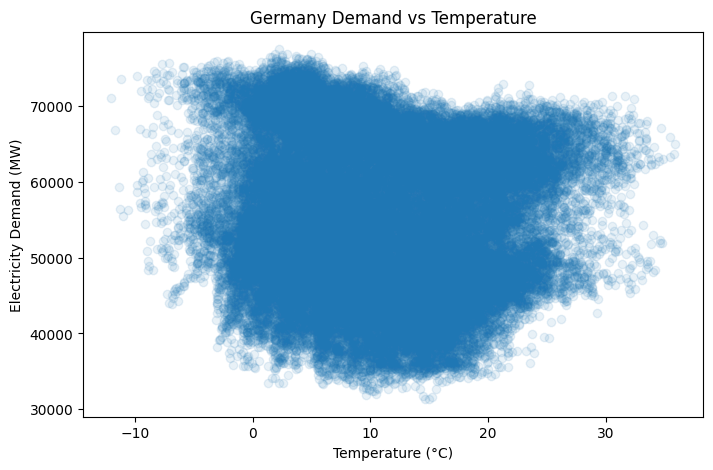

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    eda_df['temperature_C'],
    eda_df['DE_load_actual_entsoe_transparency'],
    alpha=0.1
)

plt.xlabel('Temperature (°C)')
plt.ylabel('Electricity Demand (MW)')
plt.title('Germany Demand vs Temperature')

plt.show()

*Germany electricity demand exhibits only a weak linear relationship with temperature (r = −0.07). Scatter plot analysis shows substantial variability in demand across all temperature ranges, indicating that temporal and socio-economic factors likely play a larger role than temperature alone.*

### Creating a cleaner view using average demand by temperature

In [40]:
temp_analysis = (
    eda_df
    .groupby('temperature_C')
    ['DE_load_actual_entsoe_transparency']
    .mean()
)

temp_analysis.head()

temperature_C
-12.04    71155.0
-11.76    66897.0
-11.42    59332.0
-11.32    56418.0
-11.18    73604.0
Name: DE_load_actual_entsoe_transparency, dtype: float64

### Plotting average demand vs temperature

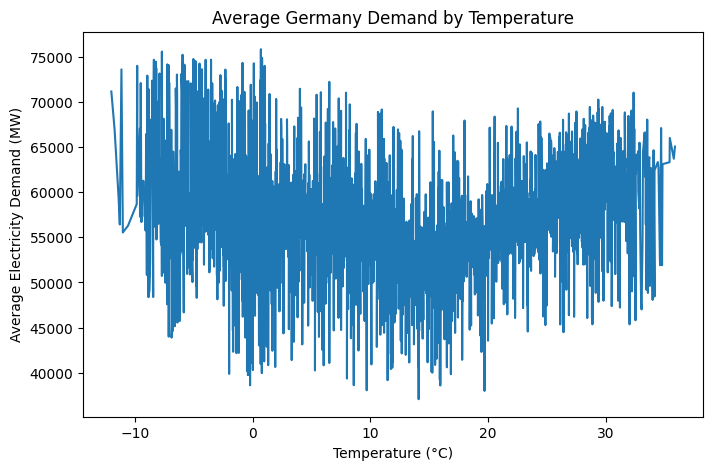

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    temp_analysis.index,
    temp_analysis.values
)

plt.xlabel('Temperature (°C)')
plt.ylabel('Average Electricity Demand (MW)')
plt.title('Average Germany Demand by Temperature')

plt.show()

*Although the linear correlation between temperature and electricity demand was weak (r = −0.07), aggregation revealed a V-shaped relationship, indicating that demand increases during both cold and hot conditions. This suggests a non-linear temperature effect on electricity consumption.*

### Analyze Demand vs Wind Generation

In [42]:
wind_corr = corr_matrix[
    'DE_load_actual_entsoe_transparency'
]['DE_wind_generation_actual']

print(wind_corr)

0.10368320616882883


*Periods with higher wind generation tend to have slightly higher electricity demand, but the relationship is weak.*

*This is not surprising because:*

*Wind generation depends primarily on weather.*   
*Electricity demand depends primarily on human activity and time patterns.*   
*Wind generation does not cause demand; it only helps meet it.*

### Visualizing Demand vs Wind Generation

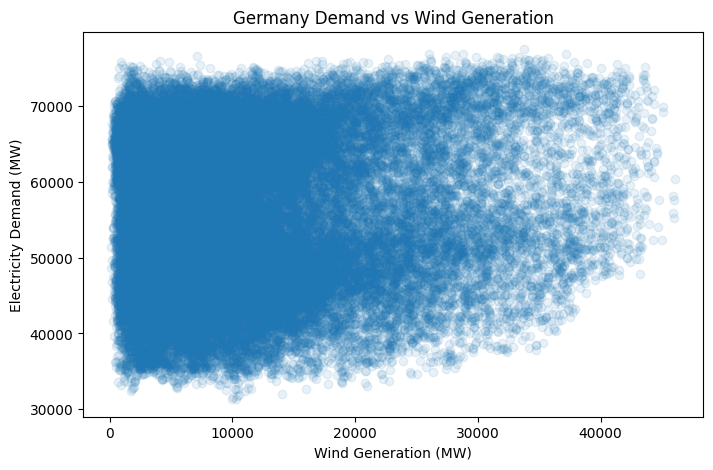

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    eda_df['DE_wind_generation_actual'],
    eda_df['DE_load_actual_entsoe_transparency'],
    alpha=0.1
)

plt.xlabel('Wind Generation (MW)')
plt.ylabel('Electricity Demand (MW)')
plt.title('Germany Demand vs Wind Generation')

plt.show()

High wind generation can occur during periods of both low and high demand. Therefore, wind availability alone is not a strong predictor of electricity consumption.

*Wind generation contains some information, but it is not a dominant driver of demand.*

### Creating a clearer wind analysis

*Instead of looking at 50,000 points, let's average demand by wind-generation level.*

In [44]:
wind_bins = pd.cut(
    eda_df['DE_wind_generation_actual'],
    bins=20
)

wind_analysis = (
    eda_df
    .groupby(wind_bins)['DE_load_actual_entsoe_transparency']
    .mean()
)

wind_analysis.head()

DE_wind_generation_actual
(89.071, 2431.45]     56330.804016
(2431.45, 4727.9]     54359.979253
(4727.9, 7024.35]     54509.388962
(7024.35, 9320.8]     54723.358113
(9320.8, 11617.25]    54901.745943
Name: DE_load_actual_entsoe_transparency, dtype: float64

### Visualizing average demand by wind generation level

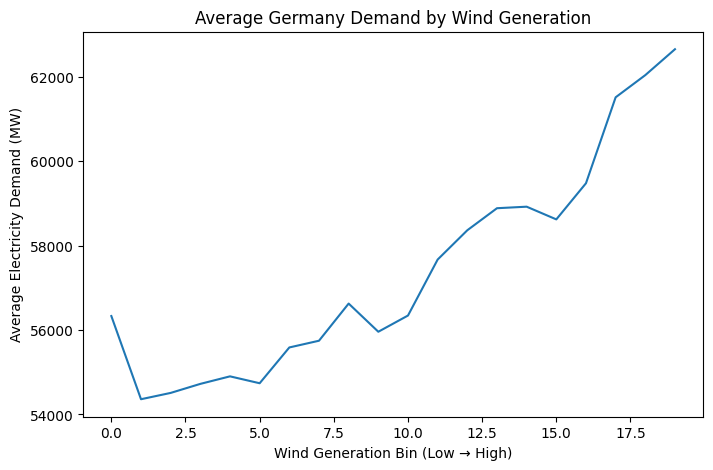

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    range(len(wind_analysis)),
    wind_analysis.values
)

plt.xlabel('Wind Generation Bin (Low → High)')
plt.ylabel('Average Electricity Demand (MW)')
plt.title('Average Germany Demand by Wind Generation')

plt.show()

*While the direct correlation between wind generation and demand was weak (r = 0.104), binning analysis revealed a gradual increase in average demand with increasing wind generation. This suggests a shared seasonal influence rather than a direct causal relationship.*

### Analyzing Demand vs Solar Generation

In [46]:
solar_corr = corr_matrix[
    'DE_load_actual_entsoe_transparency'
]['DE_solar_generation_actual']

print(solar_corr)

0.31208399210028964


### Visualizing Demand vs Solar Generation

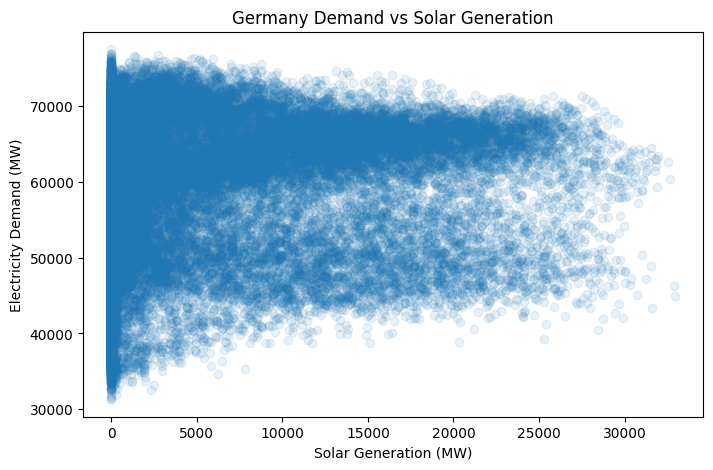

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    eda_df['DE_solar_generation_actual'],
    eda_df['DE_load_actual_entsoe_transparency'],
    alpha=0.1
)

plt.xlabel('Solar Generation (MW)')
plt.ylabel('Electricity Demand (MW)')
plt.title('Germany Demand vs Solar Generation')

plt.show()

### Creating a clearer solar generation analysis

In [48]:
solar_bins = pd.cut(
    eda_df['DE_solar_generation_actual'],
    bins=20
)

solar_analysis = (
    eda_df
    .groupby(solar_bins)['DE_load_actual_entsoe_transparency']
    .mean()
)

solar_analysis.head()

DE_solar_generation_actual
(-32.947, 1647.35]    52084.962814
(1647.35, 3294.7]     60058.208067
(3294.7, 4942.05]     60742.477568
(4942.05, 6589.4]     60919.087525
(6589.4, 8236.75]     60408.925793
Name: DE_load_actual_entsoe_transparency, dtype: float64

### Visualizing Average Demand by Solar Generation

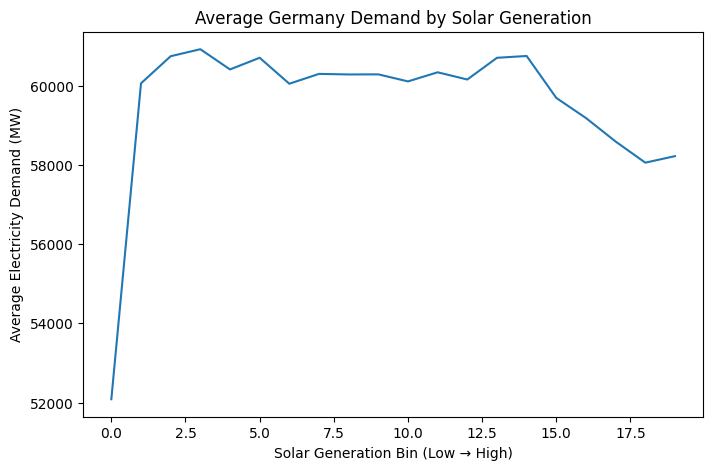

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    range(len(solar_analysis)),
    solar_analysis.values
)

plt.xlabel('Solar Generation Bin (Low → High)')
plt.ylabel('Average Electricity Demand (MW)')
plt.title('Average Germany Demand by Solar Generation')

plt.show()

### Weekend vs Weekday Demand

In [50]:
eda_df.groupby(
    'is_weekend'
)['DE_load_actual_entsoe_transparency'].mean()

is_weekend
0    58585.116972
1    47760.847500
Name: DE_load_actual_entsoe_transparency, dtype: float64

*Germany's average electricity demand is approximately 18.5% lower on weekends than on weekdays.*
*This suggests that:*

*Industrial and commercial activities are major contributors to Germany's electricity demand.*  
*Human behavior and economic activity may be more important demand drivers than weather alone.*  
*Calendar features (hour, weekday, weekend) are likely to be very valuable for forecasting models.*

### Visualizing Weekend vs Weekday Demand

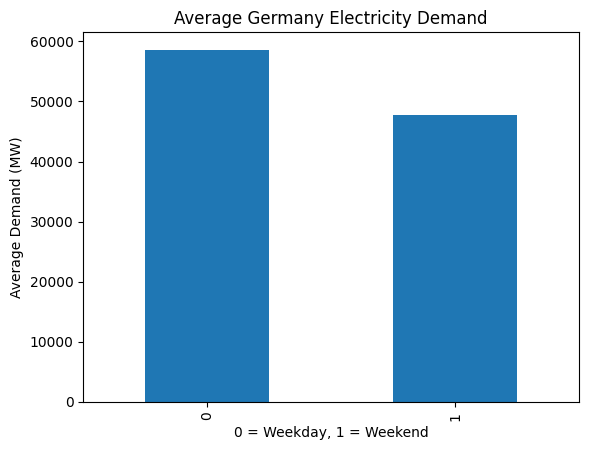

In [51]:
eda_df.groupby(
    'is_weekend'
)['DE_load_actual_entsoe_transparency'].mean().plot(
    kind='bar'
)

plt.title('Average Germany Electricity Demand')
plt.xlabel('0 = Weekday, 1 = Weekend')
plt.ylabel('Average Demand (MW)')

plt.show()

### Analyzing Seasonal Demand Patterns

In [52]:
eda_df.groupby(
    'season'
)['DE_load_actual_entsoe_transparency'].mean().sort_values(
    ascending=False
)

season
Winter    58834.343852
Autumn    56026.780069
Spring    54379.230752
Summer    53042.591561
Name: DE_load_actual_entsoe_transparency, dtype: float64

*Germany shows a clear seasonal pattern:*  

*Winter > Autumn > Spring > Summer*    
*Germany's average electricity demand is approximately 11% higher in winter than in summer.*

This supports what we observed earlier:

Germany appears to be more heating-driven than cooling-driven.  
Seasonal effects are stronger than the simple temperature correlation suggested.  
Winter demand is elevated due to lighting, heating, and increased energy consumption during colder months.

*This strongly suggests that calendar features (hour, day_of_week, month, season, is_weekend) will be very important predictors in future forecasting models.*